# Extract centerlines
This notebook is to extrack centerlines

In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import re

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack
from centerline.src.make_skeleton import make_skeleton

In [ ]:
#The cell below find images in a folder and creates an skeleton of them baseed on the h5 on that folder.
#The ouput is saved into a subfolder called centerlines where the X,Y positions are saved, as well as the filename.

2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
38208
38227
38247
38272
38274
38414
38434
188775
189209
189271
Failed centerlines:  23 
Very short centerlines: 4 
Good centerlines:  10 
Total centerlines:  37
2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.

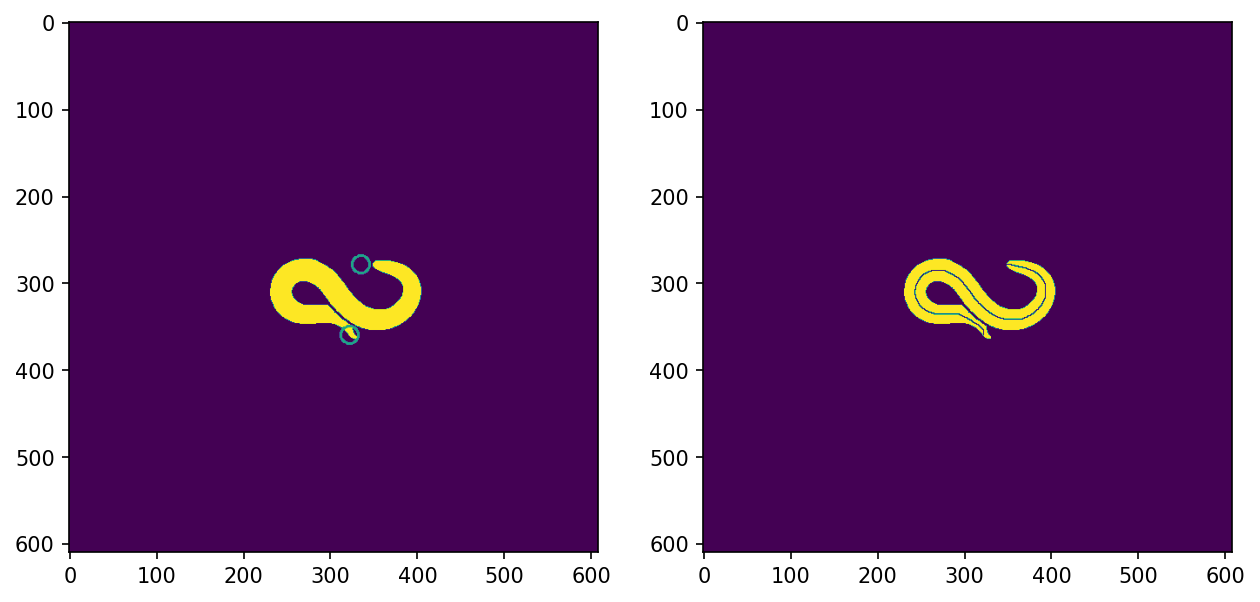

78
10804
70070
70160
70238
70422
70593
71126
118411
118457
118480
118509
118544
118660
118777
Failed centerlines:  0 
Very short centerlines: 6 
Good centerlines:  16 
Total centerlines:  22
2020-07-01_18-36-25_control_worm6-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
1
39
67
106
140
174
207
245
256
2739
2775
2798
2809
2820
2840
2842
2889
2906
2924
2948
2970
3017
3072
3110
3128
5243
5259
6961
6984
7006
7033
7070
7103
7125
21705
22015
22029
22055
22073
22091
22111
22157
22182
22250
22286
22314
24362
24444
24489
24563
24623
24743
24803
27919
27979


IndexError: list index out of range

In [186]:
import os
import glob

#define number of splines
num_splines=100

#define expected skeleton minimum length
skel_min_length=300

#Compile regular expressions into pattern objects 
regex = re.compile(r'\d+')

main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/'

for folder in natsorted(os.listdir(main_path)):
    if '.DS' in folder: continue
    print(folder)
    h5_path=glob.glob(os.path.join(main_path,folder)+'/*.h5')
    #print(os.path.join(main_path,folder))
    print(h5_path)
    print(h5_path[0])
    
    df=pd.read_hdf(h5_path[0])
    
    img_path=os.path.join(main_path,folder,'processed/')
    #print(img_path)
    
    output_path=os.path.join(main_path,folder,'centerlines/')
    #print(output_path)
    img_list=natsorted(os.listdir(img_path))

    scorer=df.columns.get_level_values(0)[0]
    head_x=df[scorer]['Head']['x'].values
    head_y=df[scorer]['Head']['y'].values
    tail_x=df[scorer]['Tail']['x'].values
    tail_y=df[scorer]['Tail']['y'].values
    
    #create writer object
    csvfileX=open(output_path+'spline_X_coords.csv','w', newline='')
    csvfileX_writer=csv.writer(csvfileX)
    csvfileY=open(output_path+'spline_Y_coords.csv','w', newline='')
    csvfileY_writer=csv.writer(csvfileY)

    csvfilename=open(output_path+'filename.csv','w', newline='')
    csvfilename_writer=csv.writer(csvfilename)
    #set counters for failed centerlines
    c1=0
    c2=0



    for filename in img_list:
        if 'img' in filename:

            #print(filename)

            i=int(regex.search(filename).group(0))
            #print(i)
            start_point=(int(head_y[i]), int(head_x[i]))
            end_point = (int(tail_y[i]), int(tail_x[i]))
            #print(start_point)
            #print(end_point)

            img=tiff.imread(os.path.join(img_path,filename))

            annotated_img=img.copy()
            cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
            cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)

    #         plt.figure(figsize=(10,10), dpi=150)
    #         plt.subplot(1,2,1)
    #         plt.imshow(annotated_img)

            u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
            #print(skel_coords[0].shape)

            #try to unpack the skel_coords as an array of int (will fail if skel_coords contains NaN)
            try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)# the dtype=int makes sures no NaN can be passed, which will cause trouble when indexing
            except:
                c1=c1+1
                #print('head and tail were too close, no centerline could be created', c1)

            else:
                #counter for short skel coords
                if len(skel_coords[0])<=skel_min_length:
                    c2=c2+1
                    #print('short centerline', c2)

                #draw zeros on the skel_img where the are coordinates
                skel_img=img.copy()
                for idx,coords in enumerate(coords):
                    skel_img[coords[0],coords[1]]=0

                #save coordinates of the good centerlines
                if len(skel_coords[0])>skel_min_length:
                    print(i)
                    x,y=np.asarray(spline_coords)
                    csvfileX_writer.writerow(x)
                    csvfileY_writer.writerow(y)
                    #would [filename] alone work? filename without[] writes every letter in a different cell
                    csvfilename_writer.writerow([os.path.join('labeled-data',folder,filename)])#(['filename:',filename])
                #plotting
                #if i!=0: continue
#                 plt.figure(figsize=(10,10), dpi=150)
#                 plt.subplot(1,2,1)
#                 plt.imshow(annotated_img)
# #                 plt.subplot(1,3,1)
# #                 plt.imshow(img)
#                 plt.subplot(1,2,2)
#                 plt.imshow(skel_img)
#                 plt.show()
                #check if the skel_coords are too short
    csvfileX.close()
    csvfileY.close()
    csvfilename.close()
    print('Failed centerlines: ', c1,'\nVery short centerlines:', c2, '\nGood centerlines: ', len(img_list)-c1-c2,'\nTotal centerlines: ', len(img_list))



# This code was in OT_annotator.ipynb notebook before


In [179]:
#make a list of strings with X0, X1..X99, and same with Y
Xlist_of_strings=[]
Ylist_of_strings=[]
XYlist_of_strings=[]
for i in np.arange(100):
    Xstring=(str(i)+'X')
    #print(string)
    Xlist_of_strings.append(Xstring)
    
    Ystring=(str(i)+'Y')
    #print(string)
    Ylist_of_strings.append(Ystring)

    
    XYlist_of_strings.append(Xstring)
    XYlist_of_strings.append(Ystring)

In [180]:
#load data with names list_of_strings
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/centerlines/'

#ATTENTION, we load spline_X_coords with names Y because DLC has X and Y inverted
X_df=pd.read_csv(csv_path+'spline_X_coords.csv', header=None, names=Ylist_of_strings)#I cant put dtype=int here because names are strings
Y_df=pd.read_csv(csv_path+'spline_Y_coords.csv', header=None, names=Xlist_of_strings)

In [164]:
X_df.head(15)

,0Y,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,...,90Y,91Y,92Y,93Y,94Y,95Y,96Y,97Y,98Y,99Y
0,235.795618,241.160999,246.132142,250.763812,255.096670,259.159050,262.968720,266.534657,269.858813,272.937885,...,287.808336,288.890867,290.300336,291.981311,293.876333,295.930584,298.096568,300.338785,302.638406,304.997951
1,229.398057,233.709701,237.856656,241.863727,245.748364,249.521390,253.187716,256.747072,260.194721,263.522185,...,287.840495,287.193843,286.918460,287.053470,287.635969,288.699883,290.274842,292.385035,295.048083,298.273896
2,225.766495,229.199075,232.817123,236.512405,240.204253,243.835976,247.371279,250.790669,254.087875,257.266261,...,289.836492,288.767786,288.017247,287.623396,287.626672,288.069295,288.995129,290.449556,292.479332,295.132459
3,217.384909,222.731794,227.715431,232.370530,236.731627,240.832430,244.705159,248.379894,251.883915,255.241052,...,294.052373,292.477587,291.123198,290.024631,289.223601,288.769051,288.718087,289.136917,290.101787,291.699916
4,216.971380,222.681579,227.837013,232.538522,236.871970,240.909257,244.709341,248.319258,251.775141,255.103237,...,294.377631,292.812004,291.430160,290.264396,289.361253,288.784818,288.620026,288.975966,289.989182,291.826975
5,192.332773,196.739551,201.151424,205.559362,209.954931,214.330224,218.677797,222.990601,227.261912,231.485273,...,324.085266,321.709685,319.534105,317.565670,315.795867,314.197698,312.722856,311.298899,309.826420,308.176225
6,193.065681,195.827145,198.741679,201.806896,205.018185,208.368873,211.850397,215.452459,219.163196,222.969340,...,328.273490,325.526421,322.964372,320.618198,318.507319,316.637031,314.995835,313.552751,312.254640,311.023525
7,321.254669,324.424781,326.892811,328.837631,330.427567,331.818172,333.150003,334.546391,336.111222,337.926706,...,373.662933,377.576735,381.305635,384.731049,387.750646,390.288423,392.304777,393.806584,394.857272,395.586897
8,386.604738,383.219901,379.619918,375.858383,371.981751,368.029820,364.036209,360.028845,356.030439,352.058971,...,390.216219,390.334913,390.590136,391.103941,391.979893,393.293044,395.079919,397.328489,399.968153,402.859718
9,360.604989,356.163954,351.785781,347.474150,343.232496,339.063965,334.971376,330.957173,327.023390,323.171598,...,387.228384,387.325124,387.698027,388.464565,389.741533,391.641709,394.270522,397.722712,402.078993,407.402716


In [165]:
Y_df.head(15)

,0X,1X,2X,3X,4X,5X,6X,7X,8X,9X,...,90X,91X,92X,93X,94X,95X,96X,97X,98X,99X
0,326.719118,327.731581,328.298252,328.459541,328.248914,327.693705,326.815932,325.633115,324.159084,322.404801,...,359.656737,363.671736,367.438635,370.867727,373.907633,376.560905,378.899634,381.081052,383.363137,386.120223
1,337.574993,336.944757,336.262713,335.516504,334.693092,333.778973,332.760398,331.623586,330.354942,328.941272,...,345.509937,349.387091,353.394879,357.474379,361.539080,365.470081,369.111296,372.264654,374.685295,376.076775
2,345.602145,344.549376,343.428633,342.252746,341.029379,339.761555,338.448185,337.084594,335.663049,334.173284,...,340.164873,344.059181,348.174272,352.455615,356.818034,361.140526,365.261079,368.971487,372.012169,374.066986
3,343.518324,344.111918,344.315321,344.189716,343.787248,343.151584,342.318476,341.316314,340.166690,338.884956,...,335.803959,339.102981,342.586198,346.249422,350.085939,354.086852,358.241426,362.537436,366.961512,371.499484
4,343.077799,344.030080,344.459770,344.460248,344.110898,343.478072,342.616046,341.567983,340.366893,339.036592,...,335.337715,338.554612,341.952327,345.532033,349.292795,353.231673,357.343825,361.622607,366.059682,370.645117
5,346.411963,347.682496,348.546620,349.074256,349.326248,349.354880,349.204380,348.911436,348.505702,348.010306,...,309.366229,311.550714,313.954583,316.594229,319.466319,322.543471,325.769918,329.057181,332.279740,335.270698
6,360.781083,359.057755,357.386736,355.791463,354.289356,352.892239,351.606751,350.434761,349.373789,348.417416,...,304.941504,306.798247,308.849389,311.143186,313.713216,316.573654,319.714542,323.097060,326.648793,330.259007
7,272.459218,269.586902,266.875686,264.183191,261.419906,258.542696,255.548324,252.466957,249.355685,246.292035,...,302.093777,302.429383,303.303702,304.728936,306.692537,309.151639,312.027481,315.199839,318.501452,321.712448
8,260.796783,261.827586,262.684651,263.415147,264.059389,264.651345,265.219150,265.785611,266.368718,266.982153,...,319.032363,323.289594,327.431587,331.365892,335.009669,338.294769,341.172820,343.620306,345.643656,347.284323
9,263.273405,262.869762,262.660051,262.648987,262.831058,263.192479,263.713158,264.368651,265.132127,265.976321,...,328.303639,332.682855,336.796201,340.525336,343.744603,346.322098,348.120723,348.999246,348.813364,347.416760


In [181]:
#concat on the axis=1 the two df
all_df=pd.concat([X_df,Y_df], axis=1)

In [167]:
all_df.head(3)

,0Y,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,...,90X,91X,92X,93X,94X,95X,96X,97X,98X,99X
0,235.795618,241.160999,246.132142,250.763812,255.096670,259.159050,262.968720,266.534657,269.858813,272.937885,...,359.656737,363.671736,367.438635,370.867727,373.907633,376.560905,378.899634,381.081052,383.363137,386.120223
1,229.398057,233.709701,237.856656,241.863727,245.748364,249.521390,253.187716,256.747072,260.194721,263.522185,...,345.509937,349.387091,353.394879,357.474379,361.539080,365.470081,369.111296,372.264654,374.685295,376.076775
2,225.766495,229.199075,232.817123,236.512405,240.204253,243.835976,247.371279,250.790669,254.087875,257.266261,...,340.164873,344.059181,348.174272,352.455615,356.818034,361.140526,365.261079,368.971487,372.012169,374.066986


In [182]:
#to reindex the columns in the correct order
all_df=all_df.reindex(columns=natsorted(all_df.columns))
    #df.reindex(index=natsorted(df.index))

In [108]:
#as a matter of fact DLC accepts sub pixel resolution, there is no need to covnert to int
#all_df=all_df[:].astype(int)

In [169]:
all_df.head(15)

,0X,0Y,1X,1Y,2X,2Y,3X,3Y,4X,4Y,...,95X,95Y,96X,96Y,97X,97Y,98X,98Y,99X,99Y
0,326.719118,235.795618,327.731581,241.160999,328.298252,246.132142,328.459541,250.763812,328.248914,255.096670,...,376.560905,295.930584,378.899634,298.096568,381.081052,300.338785,383.363137,302.638406,386.120223,304.997951
1,337.574993,229.398057,336.944757,233.709701,336.262713,237.856656,335.516504,241.863727,334.693092,245.748364,...,365.470081,288.699883,369.111296,290.274842,372.264654,292.385035,374.685295,295.048083,376.076775,298.273896
2,345.602145,225.766495,344.549376,229.199075,343.428633,232.817123,342.252746,236.512405,341.029379,240.204253,...,361.140526,288.069295,365.261079,288.995129,368.971487,290.449556,372.012169,292.479332,374.066986,295.132459
3,343.518324,217.384909,344.111918,222.731794,344.315321,227.715431,344.189716,232.370530,343.787248,236.731627,...,354.086852,288.769051,358.241426,288.718087,362.537436,289.136917,366.961512,290.101787,371.499484,291.699916
4,343.077799,216.971380,344.030080,222.681579,344.459770,227.837013,344.460248,232.538522,344.110898,236.871970,...,353.231673,288.784818,357.343825,288.620026,361.622607,288.975966,366.059682,289.989182,370.645117,291.826975
5,346.411963,192.332773,347.682496,196.739551,348.546620,201.151424,349.074256,205.559362,349.326248,209.954931,...,322.543471,314.197698,325.769918,312.722856,329.057181,311.298899,332.279740,309.826420,335.270698,308.176225
6,360.781083,193.065681,359.057755,195.827145,357.386736,198.741679,355.791463,201.806896,354.289356,205.018185,...,316.573654,316.637031,319.714542,314.995835,323.097060,313.552751,326.648793,312.254640,330.259007,311.023525
7,272.459218,321.254669,269.586902,324.424781,266.875686,326.892811,264.183191,328.837631,261.419906,330.427567,...,309.151639,390.288423,312.027481,392.304777,315.199839,393.806584,318.501452,394.857272,321.712448,395.586897
8,260.796783,386.604738,261.827586,383.219901,262.684651,379.619918,263.415147,375.858383,264.059389,371.981751,...,338.294769,393.293044,341.172820,395.079919,343.620306,397.328489,345.643656,399.968153,347.284323,402.859718
9,263.273405,360.604989,262.869762,356.163954,262.660051,351.785781,262.648987,347.474150,262.831058,343.232496,...,346.322098,391.641709,348.120723,394.270522,348.999246,397.722712,348.813364,402.078993,347.416760,407.402716


In [183]:
print(os.path.join(main_path,folder))

/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/CollectedData_Ulises.csv


In [184]:
all_df.to_csv(os.path.join(main_path,'ExtractedData_Ulises_2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.csv'))

In [55]:
#This can be deleted
#save the spline coordinates into Skeletons_training.csv
#old frames, 3 are wrong (150562, 118985, 69940)frames=[26807,27036,29100,30476,31622,33456,36437,38042,40564,48618,48847,50911,51369,52057,59853,60082,61457,63063,62603,65126,66959,67418,67876,69940,69611,72592,78783,80617,82223,84974,87267,89101,90936,96668,98503,100108,106759,108594,111805,113868,120748,121436,124876,127398,142764,150562,153314,86342,84049,82903,80839,86801,89782,95056,98725,105147,106752,119367,121660,120972,120743,118828,118844,118856,118883,118920,118958,118976,118985]
frames=[26807,27036,29100,30476,31622,33456,36437,38042,40564,48618,48847,50911,51369,52057,59853,60082,61457,63063,62603,65126,66959,67418,67876,69611,72592,78783,80617,82223,84974,87267,89101,90936,96668,98503,100108,106759,108594,111805,113868,120748,121436,124876,127398,142764,153314,86342,84049,82903,80839,86801,89782,95056,98725,105147,106752,119367,121660,120972,120743,118828,118844,118856,118883,118920,118958,118976]

#200 is for bodyparts*coordinates(100*2)
XY=np.zeros(shape=(len(frames),200))




#XY=np.asarray(XY)
for idx, frame in enumerate(natsorted(frames)):
    #print(X_df.iloc[frame].values)
    #print(Y_df.iloc[frame].values)

    #IMPORTANT X and Y have to be inverted
    XY[idx,np.arange(0,200,2)]=Y_df.iloc[frame].values #these are actually X for DLC
    XY[idx,np.arange(1,200,2)]=X_df.iloc[frame].values #these are actually Y for DLC

np.savetxt('Skeletons_training_natsorted.csv', XY, delimiter=',', fmt='%d')

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
#produce the first row of thext for the labeled-data/CollectedData.csv
for frame in natsorted(frames):
    if len(str(frame))==5:
        print('labeled-data/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/img0'+str(frame)+'.png')
    
    if len(str(frame))==6:
        print('labeled-data/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/img'+str(frame)+'.png')
    

# DataFrame Approach with Pandas

In [63]:
#this is an unfinished approach to do the same as above but by creating pandas dataframe

#scorer
scorer=['Ulises']
#bodyparts
bodyparts=[]
for i in np.arange(100):
    bodyparts.append('bodypart'+str(i))

#coordinades
coords=['x','y']

arrays=pd.MultiIndex.from_product([scorer,bodyparts, coords],

                           names=['scorer','bodyparts', 'coords'])
frames=np.arange(0,10)
skeleton_df=pd.DataFrame(index=frames, columns=arrays)

In [64]:
skeleton_df(data=np.arange(100))

TypeError: 'DataFrame' object is not callable

In [43]:
skeleton_df.head(15)

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
2               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
3               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
4               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
5               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
6               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
7               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
8               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
9               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
2               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
3               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
4               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
5               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
6               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
7               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
8               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
9               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  
2                NaN  NaN        NaN  NaN  
3                NaN  NaN        NaN  NaN  
4                NaN  NaN        NaN  NaN  
5                NaN  NaN        NaN  NaN  
6                NaN  NaN        NaN  NaN  
7                NaN  NaN        NaN  NaN  
8                NaN  NaN        NaN  NaN  
9                NaN  NaN        NaN  NaN  

[10 rows x 200 columns]

In [59]:
skeleton_df.loc[:]['Ulises']['bodypart0']['x'][:]=np.ones(10)

In [61]:
skeleton_df.iloc[:]['Ulises']['bodypart0']['x'][:]=np.ones(10)

In [62]:
skeleton_df

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
2               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
3               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
4               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
5               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
6               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
7               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
8               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
9               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
2               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
3               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
4               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
5               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
6               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
7               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
8               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
9               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  
2                NaN  NaN        NaN  NaN  
3                NaN  NaN        NaN  NaN  
4                NaN  NaN        NaN  NaN  
5                NaN  NaN        NaN  NaN  
6                NaN  NaN        NaN  NaN  
7                NaN  NaN        NaN  NaN  
8                NaN  NaN        NaN  NaN  
9                NaN  NaN        NaN  NaN  

[10 rows x 200 columns]

In [55]:
copy2

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9      1
x      1
Name: x, dtype: object

In [35]:
skeleton_df.loc(axis=1)['Ulises']['bodypart0']['x']

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: x, dtype: object

In [31]:
type(skeleton_df.loc(axis=1)['Ulises']['bodypart0']['x'])

pandas.core.series.Series

In [26]:
skeleton_df

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
2               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
3               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
4               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
5               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
6               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
7               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
8               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
9               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
2               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
3               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
4               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
5               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
6               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
7               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
8               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
9               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  
2                NaN  NaN        NaN  NaN  
3                NaN  NaN        NaN  NaN  
4                NaN  NaN        NaN  NaN  
5                NaN  NaN        NaN  NaN  
6                NaN  NaN        NaN  NaN  
7                NaN  NaN        NaN  NaN  
8                NaN  NaN        NaN  NaN  
9                NaN  NaN        NaN  NaN  

[10 rows x 200 columns]

In [177]:
skeleton_df.iloc[0]['Ulises',:] == np.nan, 

bodyparts   coords
bodypart0   x         NaN
            y         NaN
bodypart1   x         NaN
            y         NaN
bodypart2   x         NaN
                     ... 
bodypart97  y         NaN
bodypart98  x         NaN
            y         NaN
bodypart99  x         NaN
            y         NaN
Name: 0, Length: 200, dtype: object

In [201]:
df.loc[df[[0]['Ulises',:]]]=np.arange(100)

TypeError: list indices must be integers or slices, not tuple

In [209]:
skeleton_df.loc[skeleton_df['Ulises']]

ValueError: Cannot index with multidimensional key

In [193]:
skeleton_df.replace(to_replace=['Ulises','bodypart0','x'], value=1, inplace=True)

In [194]:
skeleton_df

scorer       Ulises                                                          \
bodyparts bodypart0     bodypart1     bodypart2     bodypart3     bodypart4   
coords            x   y         x   y         x   y         x   y         x   
0               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
1               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
2               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
3               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
4               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
5               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
6               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
7               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
8               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   
9               NaN NaN       NaN NaN       NaN NaN       NaN NaN       NaN   

scorer         ...                                                          \
bodyparts      ... bodypart95     bodypart96     bodypart97     bodypart98   
coords      y  ...          x   y          x   y          x   y          x   
0         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
1         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
2         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
3         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
4         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
5         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
6         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
7         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
8         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   
9         NaN  ...        NaN NaN        NaN NaN        NaN NaN        NaN   

scorer                        
bodyparts     bodypart99      
coords      y          x   y  
0         NaN        NaN NaN  
1         NaN        NaN NaN  
2         NaN        NaN NaN  
3         NaN        NaN NaN  
4         NaN        NaN NaN  
5         NaN        NaN NaN  
6         NaN        NaN NaN  
7         NaN        NaN NaN  
8         NaN        NaN NaN  
9         NaN        NaN NaN  

[10 rows x 200 columns]

In [198]:
import pandas as pd

numbers = {'set_of_numbers': [1,2,3,4,5,6,7,8,9,10]}
df = pd.DataFrame(numbers,columns=['set_of_numbers'])

print(df)

df.loc[df['set_of_numbers'] <= 4, 'set_of_numbers'] = 'True' 
#df.loc[df['set_of_numbers'] > 4, 'set_of_numbers'] = 'False' 

print (df)

   set_of_numbers
0               1
1               2
2               3
3               4
4               5
5               6
6               7
7               8
8               9
9              10
  set_of_numbers
0           True
1           True
2           True
3           True
4              5
5              6
6              7
7              8
8              9
9             10


In [178]:
skeleton_df.iloc[0]['Ulises',:].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [183]:
skeleton_df.iloc[0]['Ulises',:]=spline_coords[0]

TypeError: unhashable type: 'slice'

In [181]:
skeleton_df

scorer       Ulises                                                    \
bodyparts bodypart0      bodypart1      bodypart2      bodypart3        
coords            x    y         x    y         x    y         x    y   
0               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
1               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
2               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
3               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
4               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
5               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
6               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
7               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
8               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   
9               NaN  NaN       NaN  NaN       NaN  NaN       NaN  NaN   

scorer                    ...                                                  \
bodyparts bodypart4       ... bodypart95      bodypart96      bodypart97        
coords            x    y  ...          x    y          x    y          x    y   
0               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
1               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
2               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
3               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
4               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
5               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
6               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
7               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
8               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   
9               NaN  NaN  ...        NaN  NaN        NaN  NaN        NaN  NaN   

scorer                                     
bodyparts bodypart98      bodypart99       
coords             x    y          x    y  
0                NaN  NaN        NaN  NaN  
1                NaN  NaN        NaN  NaN  
2                NaN  NaN        NaN  NaN  
3                NaN  NaN        NaN  NaN  
4                NaN  NaN        NaN  NaN  
5                NaN  NaN        NaN  NaN  
6                NaN  NaN        NaN  NaN  
7                NaN  NaN        NaN  NaN  
8                NaN  NaN        NaN  NaN  
9                NaN  NaN        NaN  NaN  

[10 rows x 200 columns]

In [162]:
skeleton_df.iloc[0]['Ulises',:,'x']=spline_coords[0]

TypeError: unhashable type: 'slice'

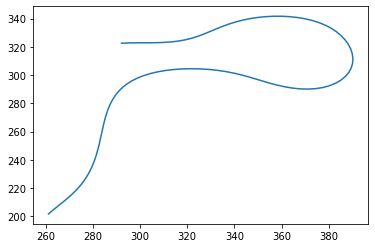

In [173]:
spline_coords[0]
plt.plot(spline_coords[0],spline_coords[1])

In [170]:
skel_coords[0].shape

(415,)